<a href="https://colab.research.google.com/github/wilszon/Clase-Inteligencia-Artificial/blob/main/Fundamento_Cuaderno_4_Tratamiento_de_Valores_At%C3%ADpicos_(Outliers).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red">Cuaderno 4: Tratamiento de Valores Atípicos (Outliers)
Los valores atípicos son observaciones que se desvían significativamente del resto de los datos. Su identificación y tratamiento son esenciales para mejorar la calidad del análisis y evitar que afecten negativamente los modelos de machine learning.


---
## <font color="red">4.1 ¿Qué es un valor atípico?
Un valor atípico es una observación que es significativamente diferente de otras en un conjunto de datos. Estos valores pueden ser resultado de errores en la recopilación de datos, variaciones extremas o fenómenos inusuales.

### Efecto de los outliers en los modelos de machine learning:
* Los modelos sensibles (regresión lineal, SVM, redes neuronales) pueden generar predicciones sesgadas debido a la influencia de estos valores.
* Los modelos basados en árboles (árboles de decisión, Random Forest) son más robustos, pero un manejo adecuado sigue siendo importante para mejorar la calidad general del análisis.


---

## <font color="red">4.2 Detección de Valores Atípicos
Existen varios métodos para detectar outliers:

### <font color="blue">4.2.1 Boxplot (Diagrama de Cajas)
El boxplot es una herramienta gráfica basada en el rango intercuartílico (IQR).
* Se consideran valores atípicos aquellos que están fuera del rango:

Bigote bajo (el primer cuartil)= $Q1−1.5×IQR$

Bogote alto (el tercer cuartil):$(Q3+1.5×IQR]$

donde Q1 es el primer cuartil y Q3 es el tercer cuartil.



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset simulado
np.random.seed(42)
data = pd.DataFrame({
    "Edad": np.round(np.random.normal(30, 10, 100).tolist() + [100, 120]),  # Valores atípicos
    "Ingresos": np.round(np.random.normal(50000, 15000, 100).tolist() + [200000, 250000])
})
data

,Edad,Ingresos
0,35.0,28769.0
1,29.0,43690.0
2,36.0,44859.0
3,45.0,37966.0
4,28.0,47581.0
...,...,...
97,33.0,52306.0
98,30.0,50873.0
99,28.0,32855.0
100,100.0,200000.0


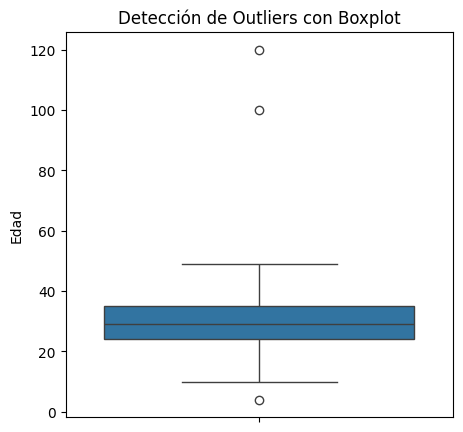

In [ ]:
# Visualizar con boxplot
plt.figure(figsize=(5, 5))
sns.boxplot(data=data, y="Edad")
plt.title("Detección de Outliers con Boxplot")
plt.show()


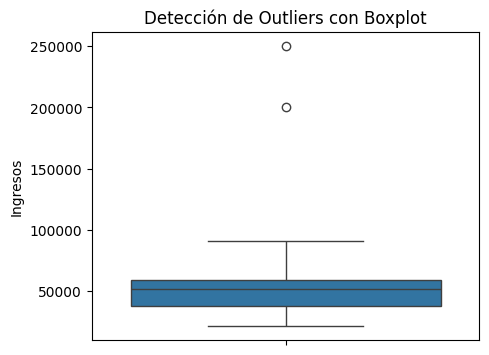

In [ ]:
# Visualizar con boxplot
plt.figure(figsize=(5, 4))
sns.boxplot(data=data, y="Ingresos")
plt.title("Detección de Outliers con Boxplot")
plt.show()


In [ ]:
import plotly.express as px

fig = px.box(y=data.Edad, title="Boxplot de Edad")
fig.show()

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,102.0,30.568627,14.516300,4.0,24.00,29.0,35.0,120.0
Ingresos,102.0,53759.372549,28376.631574,21218.0,38037.25,51900.5,59239.5,250000.0


In [ ]:
IQREdad=data["Edad"].quantile(0.75)-data["Edad"].quantile(0.25)
IQREdad
IQRIngresos=data["Ingresos"].quantile(0.75)-data["Ingresos"].quantile(0.25)
IQRIngresos

np.float64(21202.25)

In [ ]:
BSEdad=data["Edad"].quantile(0.75)+1.5*IQREdad
BSIngresos=data["Ingresos"].quantile(0.75)+1.5*IQRIngresos
BIEdad=data["Edad"].quantile(0.25)-1.5*IQREdad
BIIngresos=data["Ingresos"].quantile(0.25)-1.5*IQRIngresos
print("Bigote alto Edad:",BSEdad)
print("Bigote alto Ingresos:",BSIngresos)
print("Bigote bajo Edad:",BIEdad)
print("Bigote bajo Ingresos:",BIIngresos)

Bigote alto Edad: 51.5
Bigote alto Ingresos: 91042.875
Bigote bajo Edad: 7.5
Bigote bajo Ingresos: 6233.875


### <font color="blue">4.2.2 Z-Score (Puntuación Estándar)

El Z-Score mide cuántas desviaciones estándar se encuentra un dato con respecto a la media.

![image](https://detectoutliers.com/wp-content/uploads/2023/03/z-score-2.png)
* Un valor atípico se define como aquel cuya puntuación Z es mayor que un umbral (generalmente 3 o -3).



In [ ]:
from scipy.stats import zscore

# Calcular Z-Score
data["Edad_Zscore"] = zscore(data["Edad"])
data["Ingresos_Zscore"] = zscore(data["Ingresos"])

print("media edad:",data["Edad"].mean())
print("media Igresos:",data["Ingresos"].mean())
print("desviacion estandar edad:",data["Edad"].std())
print("desviacion estandar ingresos:",data["Ingresos"].std())
data

media edad: 30.568627450980394
media Igresos: 53759.37254901961
desviacion estandar edad: 14.51630002494742
desviacion estandar ingresos: 28376.631573948227


,Edad,Ingresos,Edad_Zscore,Ingresos_Zscore
0,35.0,28769.0,0.306776,-0.885016
1,29.0,43690.0,-0.108593,-0.356600
2,36.0,44859.0,0.376005,-0.315200
3,45.0,37966.0,0.999059,-0.559311
4,28.0,47581.0,-0.177822,-0.218803
...,...,...,...,...
97,33.0,52306.0,0.168320,-0.051470
98,30.0,50873.0,-0.039365,-0.102219
99,28.0,32855.0,-0.177822,-0.740314
100,100.0,200000.0,4.806614,5.179008


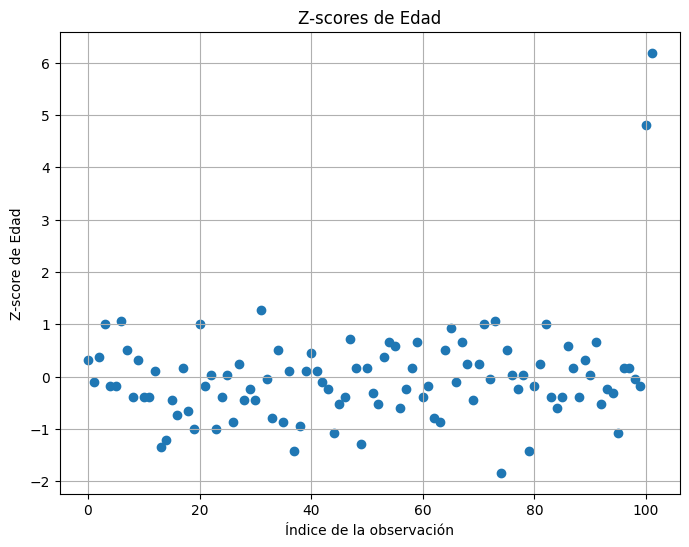

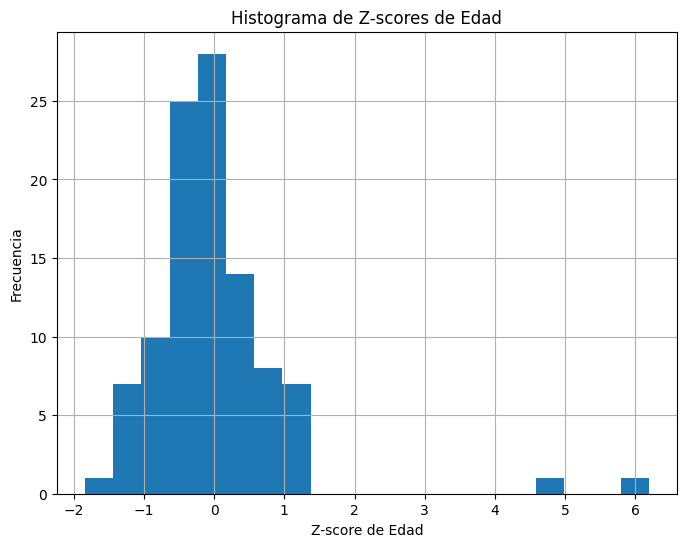

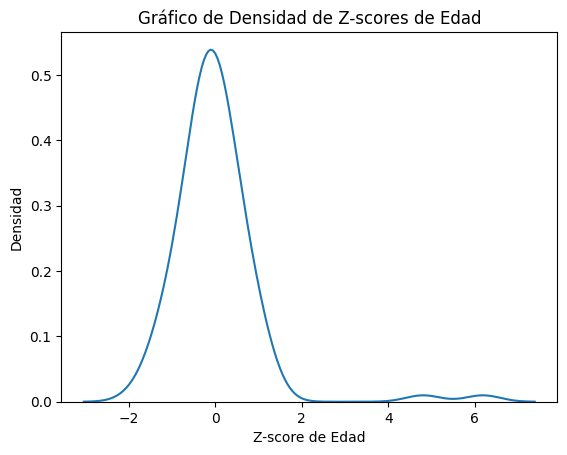

In [ ]:
# prompt: graficar los resultados de z-score en la columns Edad_Zscore

import matplotlib.pyplot as plt
# Gráfico de dispersión de Edad_Zscore
plt.figure(figsize=(8, 6))
plt.scatter(data.index, data['Edad_Zscore'])
plt.xlabel('Índice de la observación')
plt.ylabel('Z-score de Edad')
plt.title('Z-scores de Edad')
plt.grid(True)
plt.show()

# Histograma de Edad_Zscore
plt.figure(figsize=(8, 6))
plt.hist(data['Edad_Zscore'], bins=20)
plt.xlabel('Z-score de Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma de Z-scores de Edad')
plt.grid(True)
plt.show()

# Gráfico de densidad de Edad_Zscore
sns.kdeplot(data['Edad_Zscore'])
plt.xlabel('Z-score de Edad')
plt.ylabel('Densidad')
plt.title('Gráfico de Densidad de Z-scores de Edad')
plt.show()


In [ ]:
outliers_zscore = data[(np.abs(data["Edad_Zscore"]) > 3) | (np.abs(data["Ingresos_Zscore"]) > 3)]
print("Outliers detectados con Z-Score:")
print(outliers_zscore)

Outliers detectados con Z-Score:
      Edad  Ingresos  Edad_Zscore  Ingresos_Zscore
100  100.0  200000.0     4.806614         5.179008
101  120.0  250000.0     6.191179         6.949723


### <font color="blue">4.2.3  Puntuaciones IQR (Rango Intercuartílico)
El método IQR utiliza el rango entre el primer y tercer cuartil para identificar valores fuera de los límites.


In [ ]:
# Cálculo del IQR
Q1 = data["Edad"].quantile(0.25)
Q3 = data["Edad"].quantile(0.75)
IQR = Q3 - Q1

# Límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar outliers
outliers_iqr = data[(data["Edad"] < lower_bound) | (data["Edad"] > upper_bound)]
print("\nOutliers detectados con IQR:")
print(outliers_iqr)


Outliers detectados con IQR:
      Edad  Ingresos  Edad_Zscore  Ingresos_Zscore
74     4.0   54150.0    -1.839300         0.013834
100  100.0  200000.0     4.806614         5.179008
101  120.0  250000.0     6.191179         6.949723


## <font color="red">4.3 Estrategias para Manejar Outliers
Una vez identificados los valores atípicos, es importante decidir cómo manejarlos:
### <font color="blue">4.3.1 Eliminación de Outliers
Esta estrategia elimina directamente las filas con valores atípicos. Es útil cuando los valores extremos son errores de medición o no tienen relevancia en el análisis o eres un ingeniero perezoso.


In [ ]:
# Eliminar outliers basados en IQR
data_cleaned= data[(data["Edad"] > lower_bound) & (data["Edad"] < upper_bound)]
print("\nDatos después de eliminar outliers:")
data_cleaned.reset_index(drop=True, inplace=True)
data_cleaned[60:]




Datos después de eliminar outliers:


,Edad,Ingresos,Edad_Zscore,Ingresos_Zscore
60,25.0,35380.0,-0.385506,-0.650892
61,28.0,61806.0,-0.177822,0.284966
62,19.0,67379.0,-0.800876,0.482329
63,18.0,37690.0,-0.870104,-0.569085
64,38.0,64451.0,0.514461,0.378636
65,44.0,56192.0,0.929831,0.086150
66,29.0,62331.0,-0.108593,0.303558
67,40.0,78452.0,0.652918,0.874472
68,34.0,46319.0,0.237548,-0.263496
69,24.0,38694.0,-0.454735,-0.533529


In [ ]:
len(data_cleaned)

99

### <font color="blue">4.3.2 Winsorización
Consiste en reemplazar los valores extremos por los límites inferior y superior del rango aceptable.

In [ ]:
# Winsorización
data["Edad_Winsorized"] = data["Edad"].clip(lower=lower_bound, upper=upper_bound)
print("\nDatos después de Winsorización:")
data[["Edad", "Edad_Winsorized"]][60:]



Datos después de Winsorización:


,Edad,Edad_Winsorized
60,25.0,25.0
61,28.0,28.0
62,19.0,19.0
63,18.0,18.0
64,38.0,38.0
65,44.0,44.0
66,29.0,29.0
67,40.0,40.0
68,34.0,34.0
69,24.0,24.0


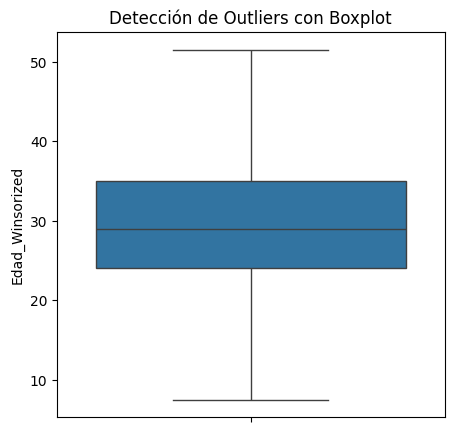

In [ ]:
#Muestro el boxplot de Edad_Winsorized
plt.figure(figsize=(5, 5))
sns.boxplot(data=data, y="Edad_Winsorized")
plt.title("Detección de Outliers con Boxplot")
plt.show()


In [ ]:
data["Ingresos_Windozarized"]=data["Ingresos"].clip(lower=BIIngresos, upper=BSIngresos)
print("\nDatos después de Winsorización:")
print(data[["Ingresos", "Ingresos_Windozarized"]])


Datos después de Winsorización:
     Ingresos  Ingresos_Windozarized
0     28769.0              28769.000
1     43690.0              43690.000
2     44859.0              44859.000
3     37966.0              37966.000
4     47581.0              47581.000
..        ...                    ...
97    52306.0              52306.000
98    50873.0              50873.000
99    32855.0              32855.000
100  200000.0              91042.875
101  250000.0              91042.875

[102 rows x 2 columns]


In [ ]:
data

,Edad,Ingresos,Edad_Zscore,Ingresos_Zscore,Edad_Winsorized,Ingresos_Windozarized
0,35.0,28769.0,0.306776,-0.885016,35.0,28769.000
1,29.0,43690.0,-0.108593,-0.356600,29.0,43690.000
2,36.0,44859.0,0.376005,-0.315200,36.0,44859.000
3,45.0,37966.0,0.999059,-0.559311,45.0,37966.000
4,28.0,47581.0,-0.177822,-0.218803,28.0,47581.000
...,...,...,...,...,...,...
97,33.0,52306.0,0.168320,-0.051470,33.0,52306.000
98,30.0,50873.0,-0.039365,-0.102219,30.0,50873.000
99,28.0,32855.0,-0.177822,-0.740314,28.0,32855.000
100,100.0,200000.0,4.806614,5.179008,51.5,91042.875


In [ ]:
data.columns

Index(['Edad', 'Ingresos', 'Edad_Zscore', 'Ingresos_Zscore', 'Edad_Winsorized',
       'Ingresos_Windozarized'],
      dtype='object')

In [ ]:
data.drop(columns=['Edad', 'Ingresos', 'Edad_Zscore', 'Ingresos_Zscore'],axis=1,inplace=True)
data

,Edad_Winsorized,Ingresos_Windozarized
0,35.0,28769.000
1,29.0,43690.000
2,36.0,44859.000
3,45.0,37966.000
4,28.0,47581.000
...,...,...
97,33.0,52306.000
98,30.0,50873.000
99,28.0,32855.000
100,51.5,91042.875


In [ ]:
data.rename(columns={'Edad_Winsorized':'Edad','Ingresos_Windozarized':'Ingresos'},inplace=True)
data

,Edad,Ingresos
0,35.0,28769.000
1,29.0,43690.000
2,36.0,44859.000
3,45.0,37966.000
4,28.0,47581.000
...,...,...
97,33.0,52306.000
98,30.0,50873.000
99,28.0,32855.000
100,51.5,91042.875


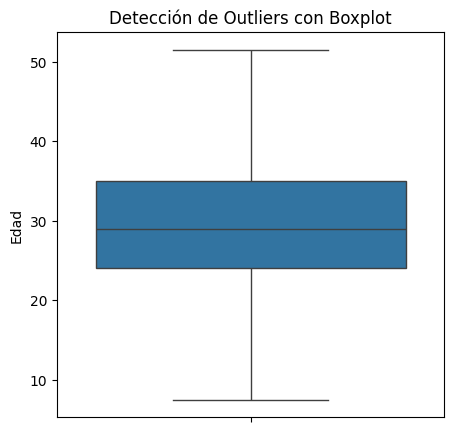

In [ ]:
# Visualizar con boxplot
plt.figure(figsize=(5, 5))
sns.boxplot(data=data, y="Edad")
plt.title("Detección de Outliers con Boxplot")
plt.show()


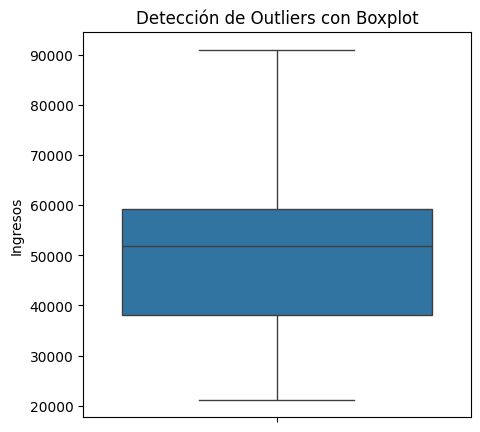

In [ ]:
# Visualizar con boxplot
plt.figure(figsize=(5, 5))
sns.boxplot(data=data, y="Ingresos")
plt.title("Detección de Outliers con Boxplot")
plt.show()


### <font color="blue">4.3.3 Imputación de Outliers
Reemplaza los valores extremos con la media, mediana u otros métodos.


In [ ]:
# Reemplazar outliers con la mediana
edad_median = data["Edad"].median()
data["Edad_Imputed"] = data["Edad"].apply(lambda x: edad_median if (x < lower_bound or x > upper_bound) else x)
print("\nDatos después de imputar outliers:")
print(data[["Edad", "Edad_Imputed"]])



Datos después de imputar outliers:
     Edad  Edad_Imputed
0    35.0          35.0
1    29.0          29.0
2    36.0          36.0
3    45.0          45.0
4    28.0          28.0
..    ...           ...
97   33.0          33.0
98   30.0          30.0
99   28.0          28.0
100  51.5          51.5
101  51.5          51.5

[102 rows x 2 columns]


## <font color="red">4.4 Visualización Comparativa del Tratamiento


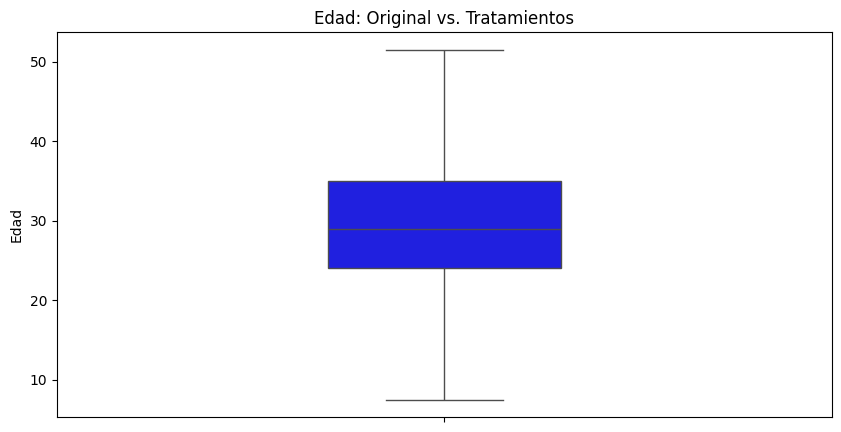

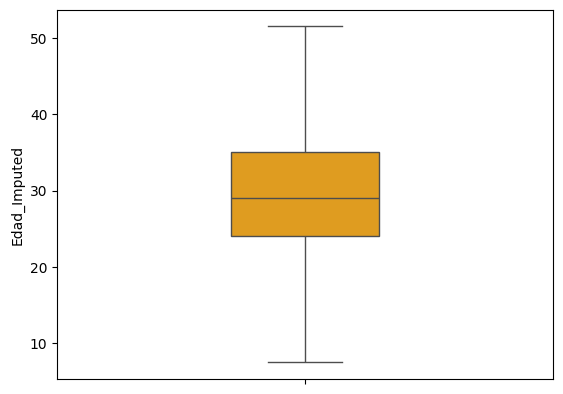

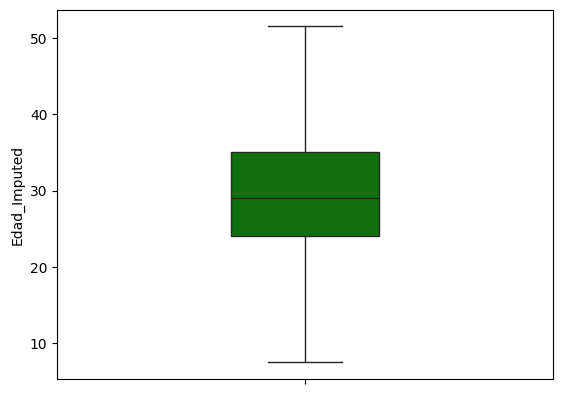

In [ ]:
# Visualizar resultados
plt.figure(figsize=(10, 5))

# Original
sns.boxplot(y=data["Edad"], color="blue", width=0.3)
plt.title("Edad: Original vs. Tratamientos")
plt.show()

# Winsorización
sns.boxplot(y=data["Edad_Imputed"], color="orange", width=0.3)
plt.show()

# Imputación
sns.boxplot(y=data["Edad_Imputed"], color="green", width=0.3)
plt.show()
